# Residência em TI - TJGO - Aprendizagem de Máquina - Notebook #1 - Titanic

### Prof. Otávio Calaça Xavier
#### <otaviocx@ufg.br>


### Todos os imports necessários para o projeto

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, f1_score, precision_score, recall_score

### Configuração de parâmetros

In [ ]:
# Exibir gráficos dentro do Jupyter Notebook
%matplotlib inline

# Definir tamanho padrão para os gráficos
rcParams['figure.figsize'] = 17, 4

### Carregando o dataset de treino

In [ ]:
dataset_original = pd.read_csv('https://raw.githubusercontent.com/otaviocx/datasets/main/titanic/train.csv')

# Eliminar o identificador dos passageiros
dataset = dataset_original.drop(['PassengerId'], axis=1)

### Análise exploratória para conhecer o dataset

In [ ]:
dataset.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
dataset.dtypes

,0
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64
Cabin,object


In [ ]:
# [0] = Quantidade de instâncias
# [1] = Quantidade de atributos
print("O dataset contém ", dataset.shape[0], "instâncias e ", dataset.shape[1], " atributos.")

O dataset contém  891 instâncias e  11  atributos.


In [ ]:
# .sample() Mostra uma amostra aleatória
# .head() Mostra as primeiras instâncias
# .tail() Mostra as últimas instâncias
dataset.sample(5)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
584,0,3,"Paulner, Mr. Uscher",male,NaN,0,0,3411,8.7125,NaN,C
579,1,3,"Jussila, Mr. Eiriik",male,32.0,0,0,STON/O 2. 3101286,7.9250,NaN,S
594,0,2,"Chapman, Mr. John Henry",male,37.0,1,0,SC/AH 29037,26.0000,NaN,S
122,0,2,"Nasser, Mr. Nicholas",male,32.5,1,0,237736,30.0708,NaN,C
132,0,3,"Robins, Mrs. Alexander A (Grace Charity Laury)",female,47.0,1,0,A/5. 3337,14.5000,NaN,S


In [ ]:
# Somente atributos numéricos são considerados
dataset.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# Quantidade absoluta
totalNulos = (dataset.isnull()).sum()
totalNulos

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,687


In [ ]:
# Percentual
percentualNulos = (totalNulos / len(dataset)) * 100
percentualNulos

,0
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000
Cabin,77.104377


In [ ]:
# Apenas atributos int e float
numericos = (dataset.select_dtypes(include=['int64', 'float64'])).columns

In [ ]:
# Apenas atributos object (string)
categoricos = (dataset.select_dtypes(include=['object'])).columns

# Não considerar os atributos textuais Name, Ticket e Cabin entre os atributos categóricos
categoricos = categoricos.drop(['Name', 'Ticket', 'Cabin'])

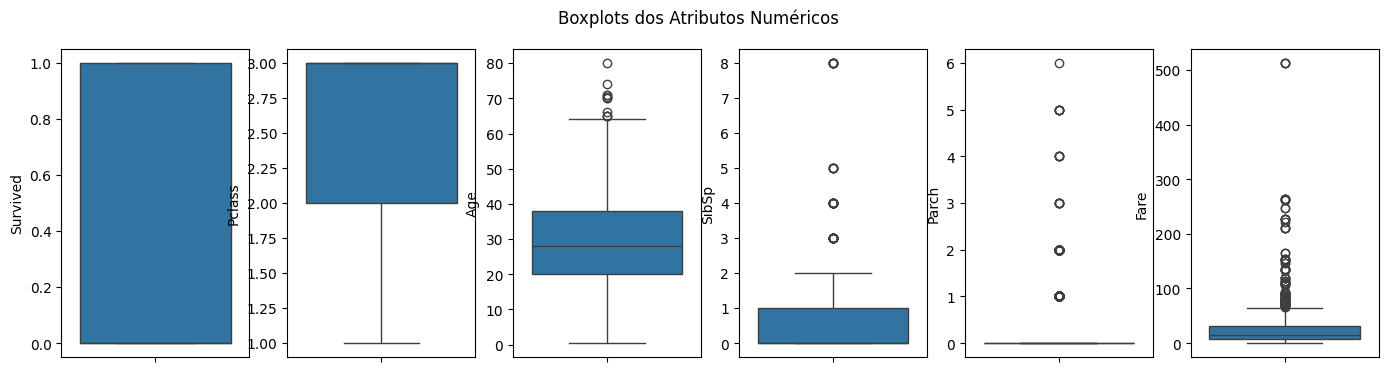

In [ ]:
fig, ax = plt.subplots(ncols=len(numericos), nrows=1)
plt.suptitle("Boxplots dos Atributos Numéricos")

# Gráfico para cada atributo numérico
for i in range(0, len(numericos)):
    feature = numericos[i]
    sns.boxplot(dataset[feature], ax=ax[i])

Os boxplots acima mostram ainda mais claramente a existência de outliers para Age, SibSp, Parch e Fare, principalmente para as 3 últimas. Em etapas posteriores, pode ser que seja necessário realizar algum tratamento nas instâncias que apresentam esse tipo de comportamento.

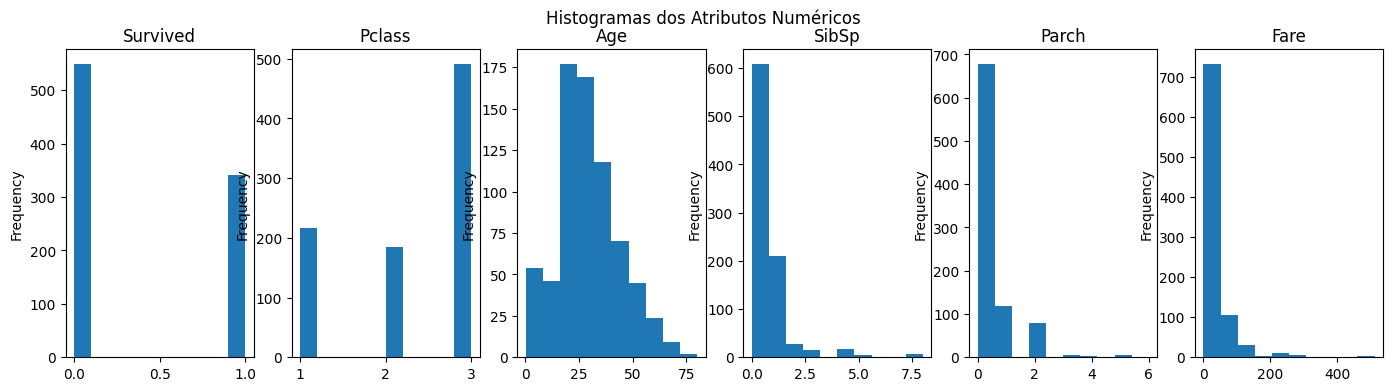

In [ ]:
fig, ax = plt.subplots(ncols=len(numericos), nrows=1)
plt.suptitle("Histogramas dos Atributos Numéricos")

# Histograma para cada atributo numérico
for i in range(0, len(numericos)):
    feature = numericos[i]
    ax[i].set_title(feature)
    dataset[feature].plot(kind='hist', ax=ax[i])

Analisando as distribuições, temos que:

    Existiam mais passageiros na terceira classe do que nas outras 2
    A variável Age é a que mais se aproxima de uma Distribuição Normal
    SibSp, Parch e Fare possuem, em sua maioria, valores pequenos

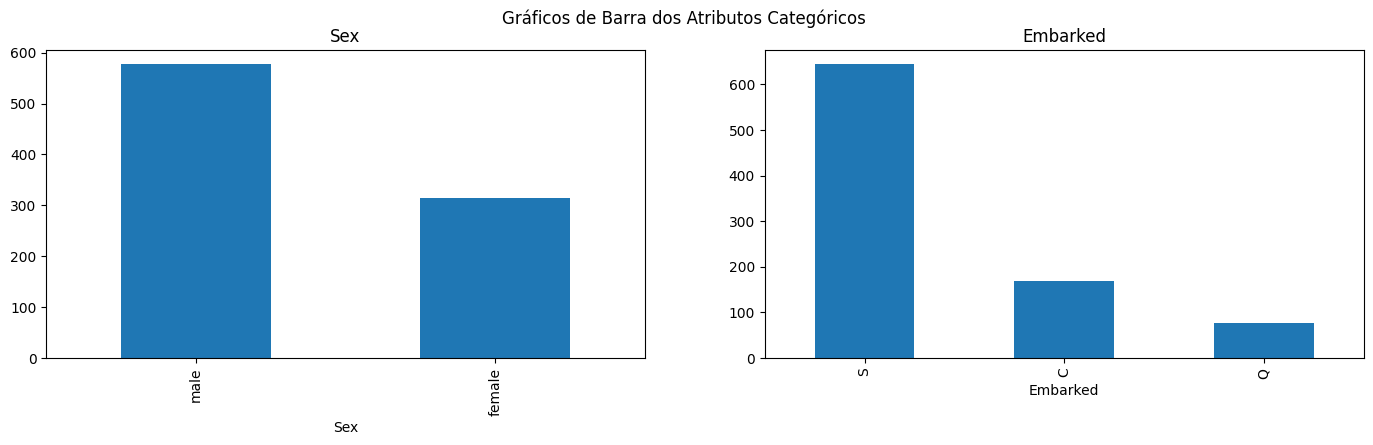

In [ ]:
fig, ax = plt.subplots(ncols=len(categoricos), nrows=1)
plt.suptitle("Gráficos de Barra dos Atributos Categóricos")

# Gráfico para cada atributo categórico
for i in range(0, len(categoricos)):
    feature = categoricos[i]
    ax[i].set_title(feature)
    dataset[feature].value_counts().plot(kind='bar', ax=ax[i])

Existiam mais homens do que mulheres a bordo e a maioria dos passageiros embarcaram em "S" (Southampton)


<Axes: >

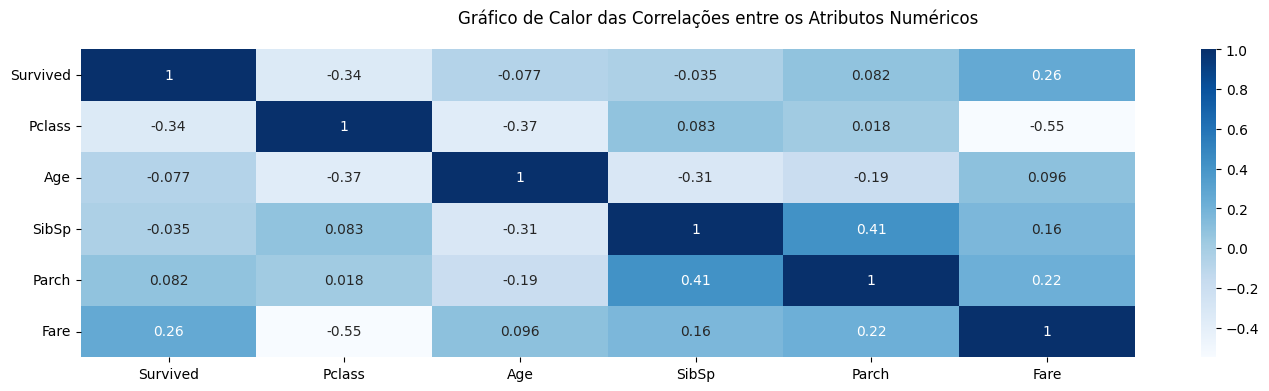

In [ ]:
# Somente atributos numéricos são considerados
plt.suptitle("Gráfico de Calor das Correlações entre os Atributos Numéricos")
numeric_dataset = dataset.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_dataset.corr(), annot=True, cmap='Blues')

O gráfico de calor mostra que as variáveis mais correlacionadas são Pclass e Fare (negativamente) e SibSp e Parch (positivamente).

## Pré-Processamento

In [ ]:
dataset_original.shape

(891, 12)

In [ ]:
# removendo features que não serão utilizadas no treinamento
dataset = dataset_original.drop(['Name', 'Ticket', 'Cabin', 'PassengerId'], axis=1)
dataset.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [ ]:
# divisão do dataset em treino e teste
train, test_split = train_test_split(dataset.copy(), test_size=0.3)

In [ ]:
train.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,128
SibSp,0
Parch,0
Fare,0
Embarked,1


In [ ]:
# Para as instâncias onde Age é nulo, imputar a média (29.97)
train.loc[train['Age'].isnull(), 'Age'] = train['Age'].mean()

In [ ]:
# Para as instâncias onde Embarked é nulo, imputar a moda (S)
train.loc[train['Embarked'].isnull(), 'Embarked'] = (train.mode())['Embarked'][0]

# normalizando os dados
train = pd.get_dummies(train)

# Evitar dummy trap excluindo valores de referência
train.drop(['Sex_male', 'Embarked_S'], axis=1, inplace=True)
train.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Embarked_C,Embarked_Q
716,1,1,38.000000,0,0,227.525,True,True,False
232,0,2,59.000000,0,0,13.500,False,False,False
863,0,3,29.240909,8,2,69.550,True,False,False
447,1,1,34.000000,0,0,26.550,False,False,False
752,0,3,33.000000,0,0,9.500,False,False,False


In [ ]:
# separando o target do treinamento
X = train.drop(['Survived'], axis=1)
y = train['Survived']

### Treinamento do modelo

In [ ]:
# treinamento do modelo com Random Forest
model = RandomForestClassifier(random_state=1)
model.fit(X, y)

RandomForestClassifier(random_state=1)

### Avaliação do modelo com o dataframe de testes

In [ ]:
y_pred = model.predict(X)

In [ ]:
# acurácia
accuracy_score(y, y_pred)

0.9887640449438202

In [ ]:
# Imputar valores nulos usando padrões do conjunto de treino
test_split.loc[test_split['Age'].isnull(), 'Age'] = 29.97
test_split.loc[test_split['Embarked'].isnull(), 'Embarked'] = 'S'

# Transformar variáveis categóricas
test_split = pd.get_dummies(test_split)
test_split.drop(['Embarked_S', 'Sex_male'], inplace=True, axis=1)

In [ ]:
test_split.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Embarked_C,Embarked_Q
465,0,3,38.00,0,0,7.0500,False,False,False
762,1,3,20.00,0,0,7.2292,False,True,False
806,0,1,39.00,0,0,0.0000,False,False,False
400,1,3,39.00,0,0,7.9250,False,False,False
803,1,3,0.42,0,1,8.5167,False,True,False


In [ ]:
X_test = test_split.drop(['Survived'], axis=1)
y_test = test_split['Survived']

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pred)

0.7985074626865671